# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [5]:
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('Y_train_balanced.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('Y_test.csv')

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Para aplicação do modelo da árvore de decisão é preciso:
Definir o objetivo(o que se quer prever), conhecer as variáveis: fazer uma pequena investigação no tipo dos dados como eles estão se comportando, como é a correlação entre eles.
Preparar os dados: remover as colunas que não serão usadas, tratar os valores ausentes(substituir pela média, moda ou apenas remover),tratar os dados categóricos, verificar inconsistências, tratar os outliers. 
Separar em treino e teste:  fazendo o balanceamento só do treino.
Treinar o modelo: definir os hiperparâmetros, testar o modelo. 
Avaliar o modelo a partir da acurácia, recall e f1, reajustar os parâmetros(pode diminuir a profundidade e modificar o mínimo por folha, adicionar gini para melhorar a qualidade da divisão) para melhorar o modelo e repetir os testes na base treino.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [6]:
arvore_credito = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_credito.fit(X_train, y_train)
previsoes = arvore_credito.predict(X_train)
acuracia = accuracy_score(y_train,previsoes)
print("Acurácia", acuracia)




Acurácia 1.0


O modelo atingiu o objetivo sendo 100% eficiente e acertando todas as tentativas de identificação dentro do conjunto de teste. Como já explorado no módulo anterior após investigação esse valor tão alto pode ser um reflexo dos poucos registros, das variáveis possuírem boa separação entre as classes, além do próprio fato do o modelo está sendo testado nos próprios dados que ele já viu durante o treinamento. Todos esses fatores normalmente vão gerar métricas artificialmente altas. 

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [18]:
arvore_credito2 = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_credito2.fit(X_test, y_test)
previsoes2 = arvore_credito2.predict(X_test)
acuracia2 = accuracy_score(y_test,previsoes2)
print("Acurácia", acuracia2)


Acurácia 1.0


O modelo também atingiu o objetivo sendo 100% eficiente e acertando todas as tentativas de identificação dentro do conjunto de teste. 

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

Sim, é possível. O caminho mais longo da raiz até as folhas possui 4 divisões. O fato do imóvel não ser alugado já melhora a classificação colocando como Average, seguido da renda como segundo fator decisório que para níveis maiores entra também o nível de escolaridade para melhorar os resultados. Por fim, a faixa de renda e idade completam a avaliação de risco nos casos em que a renda é maior que 43750.00. 

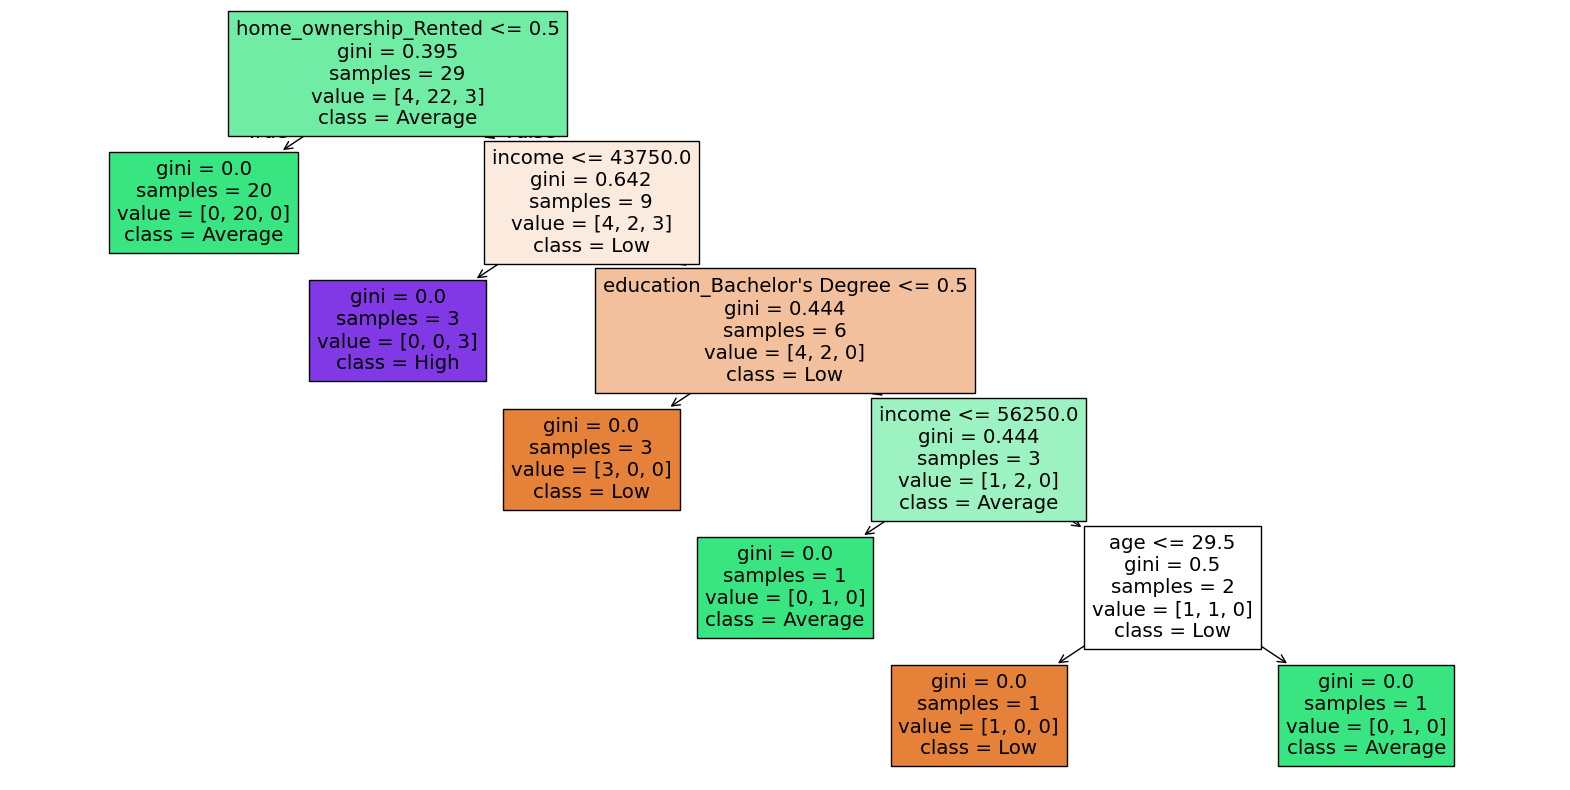

In [8]:
plt.figure(figsize = (20,10))
plot_tree(
    arvore_credito2,
    filled=True,
    feature_names=X_train.columns,
    class_names=['Low', 'Average', 'High']
)
plt.show()

In [13]:
print(y_test.columns)

Index(['credit_score'], dtype='str')


# 6) Identifique as 2 principais features do modelo.


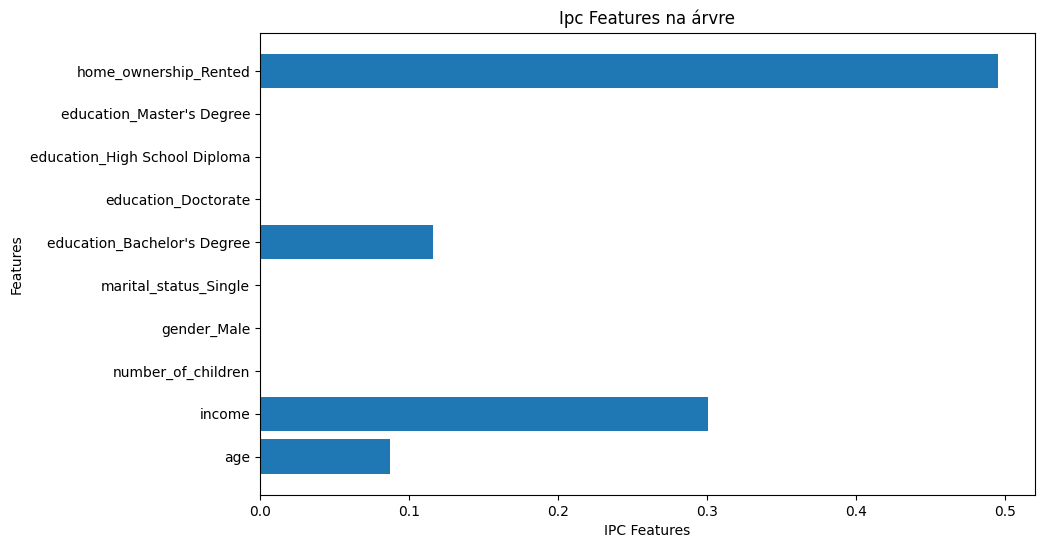

In [12]:
importancias_features = arvore_credito2.feature_importances_
nomes_features = X_train.columns

plt.figure(figsize =(10,6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('IPC Features')
plt.ylabel('Features')
plt.title('Ipc features na árvore')
plt.show()


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [15]:
X_train_reduzido = X_train[['home_ownership_Rented', 'income']]
X_test_reduzido = X_test[['home_ownership_Rented', 'income']]
arvore_churn_reduzido = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore_churn_reduzido.fit(X_train_reduzido, y_train)

previsoes_reduzido = arvore_churn_reduzido.predict(X_test_reduzido)

print('Relatório de Classificação')
print(classification_report(y_test, previsoes_reduzido))

matriz_confusao = confusion_matrix(y_test, previsoes_reduzido)
print(matriz_confusao)


Relatório de Classificação
              precision    recall  f1-score   support

     Average       0.80      1.00      0.89         4
        High       1.00      0.95      0.98        22
         Low       1.00      1.00      1.00         3

    accuracy                           0.97        29
   macro avg       0.93      0.98      0.96        29
weighted avg       0.97      0.97      0.97        29

[[ 4  0  0]
 [ 1 21  0]
 [ 0  0  3]]


Quanto a precisão o novo modelo acertou 80% as previsões para average(80% do que disse que era realmente era), 100% para high and low. Já analisado com o recall o modelo acertou 100% de average e low e 95% do que disse ser high estava correto. Uma acurácia de 0.97 ("que vem de f1score")mostra que 97% das previsões do modelo estavam corretas.A macro avg("que vem de recall e f1-score") também mostra o bom desempenho do modelo.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

No módulo 20 o modelo possuia: 
Acurácia 0.9655172413793104
Recall 0.9848484848484849
No módlo 21:
Acurácia 1.0
O que já podia ser cnsiderado um resultado fora da curva e suspeito tendo em vista a "alta performance" do modelo aqui usando a árvore de decisão mesmo não só usando as variáveis com mais importância o modelo atingiu 100% de acertos. Isso se deve a maior flexibilidade dos modelos de árvore de decisão que podem capturar relações mais complexas entre as variáveis de entrada e saída. O naivebayes ao contrário assume independência condicional entre as variáveis de entrada. Portanto em cenários onde existem interações complexas entre as variáveis a árvore pode asimilar melhor essas características.